<a href="https://colab.research.google.com/github/mukeshdhadhariya/college_mini_project/blob/main/College_projcet_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

In [ ]:
df = pd.read_csv("bank-additional-full.csv", sep=';')

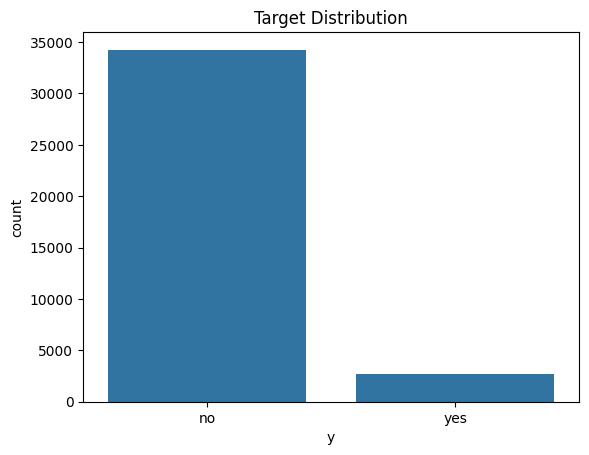

In [ ]:
sns.countplot(x='y', data=df)
plt.title("Target Distribution")
plt.show()

In [ ]:
# -----------------------------
# 3. Feature Engineering
# -----------------------------
df['age_group'] = pd.cut(df['age'], bins=[0,25,40,60,100], labels=[0,1,2,3])

In [ ]:
# -----------------------------
# 4. Split Features
# -----------------------------
# Map 'y' to numerical
y_mapped = df['y'].map({'yes':1, 'no':0})

# Combine df and y_mapped to drop rows where y_mapped is NaN
df_temp = df.copy()
df_temp['y_mapped'] = y_mapped
df_temp.dropna(subset=['y_mapped'], inplace=True)

# Now create X and y from the cleaned temporary DataFrame
X = df_temp.drop(['y', 'y_mapped'], axis=1)
y = df_temp['y_mapped']

cat_cols = X.select_dtypes(include=['object']).columns
num_cols = X.select_dtypes(exclude=['object']).columns

In [ ]:
# -----------------------------
# 5. Preprocessing Pipeline
# -----------------------------
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

In [ ]:
# -----------------------------
# 6. Models
# -----------------------------
models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier()
}

for name, model in models.items():
    pipe = Pipeline([
        ('prep', preprocessor),
        ('model', model)
    ])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    print(f"\n{name} Accuracy:", accuracy_score(y_test, preds))


Logistic Accuracy: 0.939935064935065

RandomForest Accuracy: 0.9408820346320347


In [ ]:
# -----------------------------
# 7. Hyperparameter Tuning
# -----------------------------
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [5, 10, 15]
}

rf_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

grid = GridSearchCV(rf_pipeline, param_grid, cv=3, scoring='accuracy')
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'model__max_depth': 15, 'model__n_estimators': 200}


In [ ]:
# -----------------------------
# 8. Final Model
# -----------------------------
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print("\nFinal Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Final Accuracy: 0.9396645021645021
ROC AUC: 0.6098036781527657
              precision    recall  f1-score   support

         0.0       0.95      0.99      0.97      6893
         1.0       0.65      0.23      0.34       499

    accuracy                           0.94      7392
   macro avg       0.80      0.61      0.65      7392
weighted avg       0.93      0.94      0.93      7392



### 9. Input and Output Visualization

Let's visualize some aspects of our input data and the model's output.

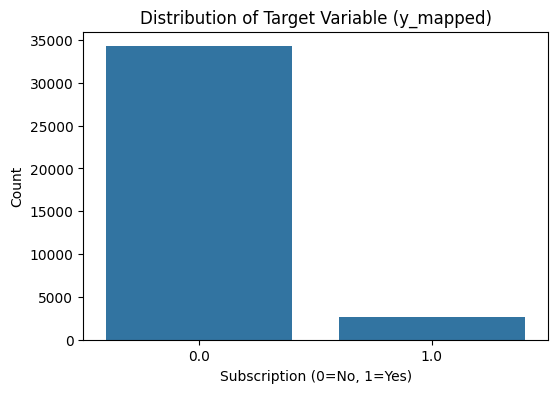

In [ ]:
# Visualize the distribution of the target variable (after cleaning)
plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title('Distribution of Target Variable (y_mapped)')
plt.xlabel('Subscription (0=No, 1=Yes)')
plt.ylabel('Count')
plt.show()

Let's visualize the distribution of a few key input features:

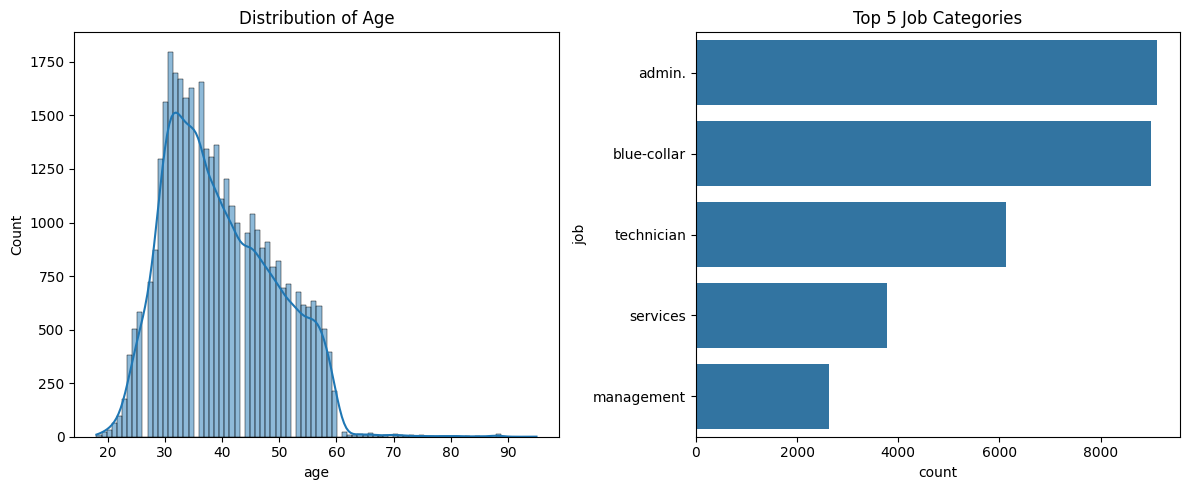

In [ ]:
# Visualize distribution of 'age'
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(X['age'], kde=True)
plt.title('Distribution of Age')

# Visualize distribution of 'job' (top 5)
plt.subplot(1, 2, 2)
sns.countplot(y=X['job'], order=X['job'].value_counts().index[:5])
plt.title('Top 5 Job Categories')
plt.tight_layout()
plt.show()

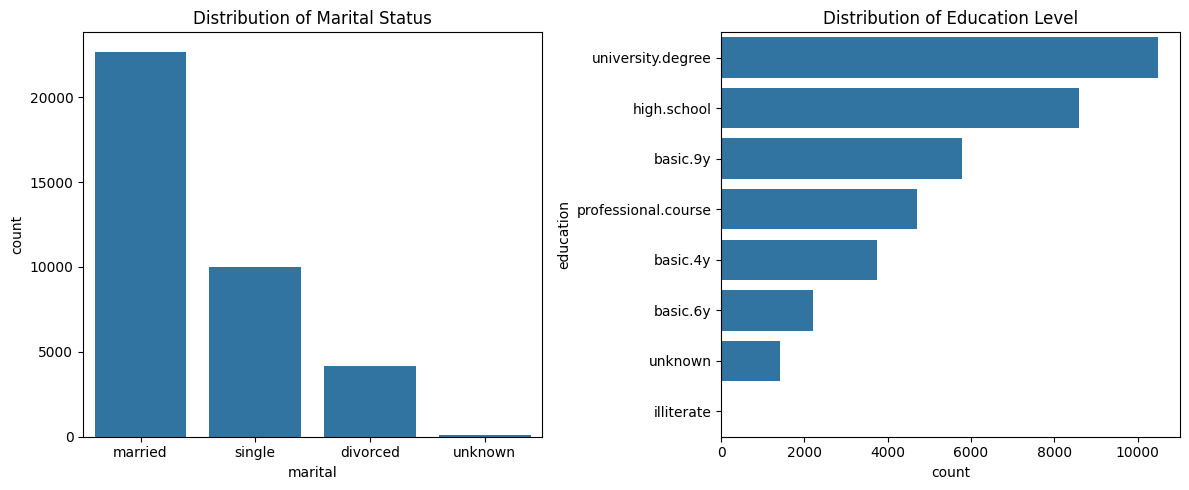

In [ ]:
# Visualize distribution of 'marital' and 'education'
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x=X['marital'])
plt.title('Distribution of Marital Status')

plt.subplot(1, 2, 2)
sns.countplot(y=X['education'], order=X['education'].value_counts().index)
plt.title('Distribution of Education Level')
plt.tight_layout()
plt.show()

Finally, let's visualize the model's performance by comparing predicted values (`y_pred`) with actual test values (`y_test`) using a confusion matrix.

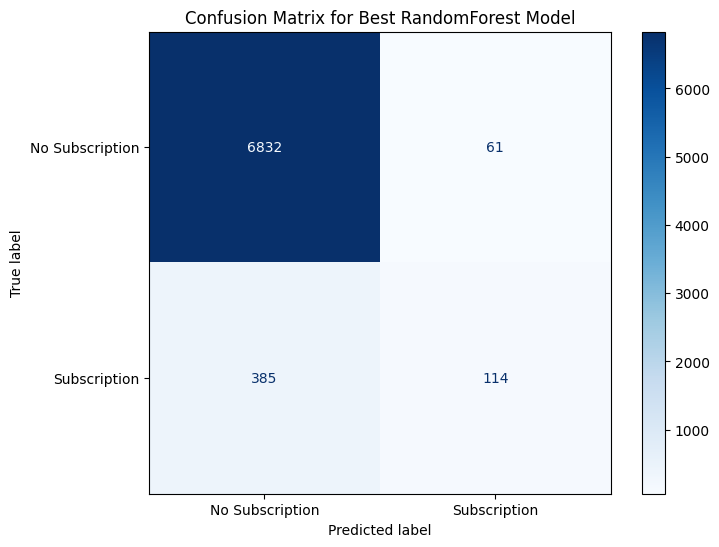

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Subscription', 'Subscription'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Confusion Matrix for Best RandomForest Model')
plt.show()

In [ ]:
for i in range(y_pred.size):
  if y_pred[i]==1:
    print(i)
    break

38


In [ ]:
df.head(5)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,age_group
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,2
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,2
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,1
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,1
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,2
